# Python Lesson 62: Correlation, Covariance Matrix and the Multivariate Gaussian

**Concept page:** `wiki/concepts/correlation-and-covariance-matrix.md` · **Area:** probability

**You will be able to:**
- compute covariance and correlation with a consistent divisor
- build a covariance matrix
- sample from a multivariate Gaussian

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Age vs height, grades, naps

In [2]:
age=np.arange(6,16); h=np.array([50,52,55,57,60,62,64,65,67,68]); gr=np.array([5,7,8,3,1,1,6,10,2,7]); nap=np.array([8,7,6,5,4,3,2,1,1,0])
for nm,y in (('height',h),('grades',gr),('naps',nap)):
    cov_pop=np.mean((age-age.mean())*(y-y.mean())); print(nm,'cov(n)=',round(cov_pop,3),'corr=',round(np.corrcoef(age,y)[0,1],3))
# mixing divisors (cov with n, variances with n-1) does NOT give the correlation
bad=17/np.sqrt(age.var(ddof=1)*h.var(ddof=1)); print('inconsistent divisors give',round(bad,3))

height cov(n)= 17.0 corr= 0.992
grades cov(n)= 0.1 corr= 0.012
naps cov(n)= -7.45 corr= -0.994
inconsistent divisors give 0.893


## 2. Covariance matrix

In [3]:
X=np.c_[age,h,gr]; S=np.cov(X.T); print(S.round(2)); assert np.allclose(S,(X-X.mean(0)).T@(X-X.mean(0))/(len(X)-1))
w,v=np.linalg.eigh(np.cov(np.c_[age,h].T)); print('eigenvalues (PCA variances):',w)

[[ 9.17 18.89  0.11]
 [18.89 39.56 -1.  ]
 [ 0.11 -1.    9.78]]
eigenvalues (PCA variances): [ 0.1194 48.6028]


## 3. Games from the lecture

In [4]:
def cov_game(p,xs,ys):
    p=np.array(p);xs=np.array(xs);ys=np.array(ys); return (p*xs*ys).sum()-(p*xs).sum()*(p*ys).sum()
print(cov_game([.5,.5],[1,-1],[1,-1]),cov_game([.5,.5],[1,-1],[-1,1]),cov_game([.25]*4,[1,1,-1,-1],[1,-1,1,-1]),cov_game([1/2,1/3,1/6],[1,-1,0],[1,-1,0]))

1.0 -1.0 0.0 0.8055555555555555


## 4. Multivariate Gaussian samples

[[0.98 0.81]
 [0.81 1.02]] 0.8


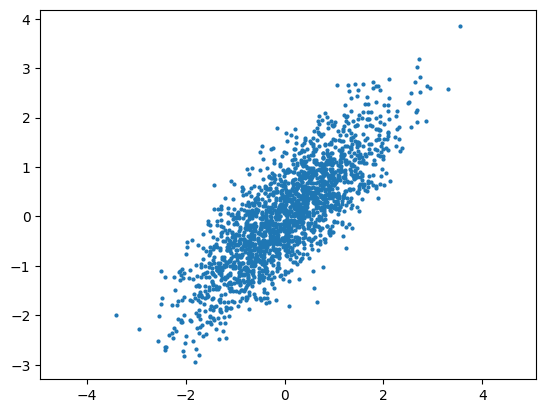

In [5]:
rng=np.random.default_rng(0); mu=[0,0]; Sig=[[1,.8],[.8,1]]
pts=rng.multivariate_normal(mu,Sig,2000); print(np.cov(pts.T).round(2),np.corrcoef(pts.T)[0,1].round(2))
plt.scatter(*pts.T,s=4); plt.axis('equal'); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 basic (Cambodia) gives the mean point $M(\bar x,\bar y)$ and least-squares line; covariance/(variance) is exactly its slope: $a=\mathrm{Cov}(x,y)/\mathrm{Var}(x)$.

In [6]:
print(np.polyfit(age,h,1)[0], np.cov(age,h,ddof=0)[0,1]/age.var())

2.0606060606060606 2.0606060606060606


## Exercises

**Exercise 1.** Show the correlation is unchanged if height is measured in cm instead of inches (units cancel).

In [7]:
# your code here

**Exercise 2.** Find two variables with covariance 0 but strong dependence: X uniform on [-1,1], Y=X^2.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
print(np.corrcoef(age,h)[0,1],np.corrcoef(age,h*2.54)[0,1]); assert np.isclose(np.corrcoef(age,h)[0,1],np.corrcoef(age,h*2.54)[0,1])

0.991966368448098 0.9919663684480979


In [10]:
# Solution 2
x=np.linspace(-1,1,10001); y=x**2; print(np.cov(x,y)[0,1]); assert abs(np.cov(x,y)[0,1])<1e-12

7.815970093361103e-18
